In [161]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import mytools
from scipy.optimize import curve_fit




In [162]:
data_dir = '/Users/mghrear/data/HPS_data/ensemble/'

In [163]:
fit_ranges = {
    13: (1000, 1045, 200000),
    15: (1000, 1045, 100000),
    17: (995, 1045, 100000),
    23: (1000, 1045, 200000),
    26: (1010, 1045, 400000),
    28: (1005, 1045, 400000),
    32: (1005, 1045, 200000),
    36: (1005, 1045, 300000),
    37: (1010, 1050, 400000),
    39: (1000, 1045, 400000),
    40: (1005, 1045, 300000),
    41: (1005, 1040, 400000),
    43: (1000, 1045, 350000),
    45: (1000, 1045, 400000),
    46: (1005, 1045, 400000),
    56: (1005, 1045, 400000),
    68: (995,  1045, 400000),
    73: (1010, 1045, 200000),
    75: (1000, 1040, 200000),
    77: (993,  1060, 200000),
    80: (1005, 1045, 400000),
    82: (1005, 1045, 400000),
    88: (1000, 1045, 200000),
    91: (1000, 1045, 400000),
    93: (1005, 1045, 300000),
    95: (1005, 1045, 200000),
    99: (1005, 1045, 400000),
    100: (1000, 1045, 200000),
    101: (1005, 1045, 200000)
    }

Signal yield : 6506.1 ± 1044.5
Mean         : 1019.243 ± 0.582 MeV
Sigma        : 7.651 ± 0.831 MeV
χ²/ndf       : 39.2 / 35 = 1.12  (p = 0.286)


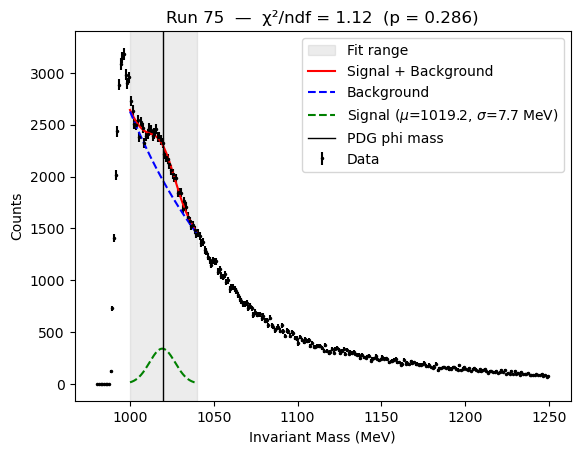

In [167]:
run_number = 75



m_phi = 1019.461
m_lo, m_hi, num = fit_ranges[run_number]  # fit window in MeV
bin_width = 1            # MeV per bin

df = pd.read_pickle(data_dir + f'ANN_ensemble_run{run_number}_selected.pk')
df = df.loc[df.pos_E_Ecal > 0.6]
df.InvM = df.InvM * 1000
df_cut = df.nlargest(num, 'ANN_pred')


bins = np.arange(m_lo, m_hi + bin_width, bin_width)
counts, edges = np.histogram(df_cut.InvM, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
errors = np.where(counts > 0, np.sqrt(counts), 1)  # Poisson errors, floor at 1

def signal(m, n_sig, mu, sigma):
    return n_sig / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((m - mu) / sigma) ** 2)

def background(m, n_bkg, lam):
    return n_bkg * lam * np.exp(-lam * (m - m_lo))

def model(m, n_sig, mu, sigma, n_bkg, lam):
    return signal(m, n_sig, mu, sigma) + background(m, n_bkg, lam)

p0     = [1000,  m_phi, 5,   counts.sum(), 1/30]
bounds = ([0,    1000,  0.1, 0,            0   ],
          [np.inf, 1060, 50, np.inf,       1   ])

popt, pcov = curve_fit(model, centers, counts, p0=p0, sigma=errors,
                       absolute_sigma=True, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
n_sig, mu, sigma, n_bkg, lam = popt
n_sig_err, mu_err, sigma_err = perr[:3]

chi2 = np.sum(((counts - model(centers, *popt)) / errors) ** 2)
ndf  = len(counts) - len(popt)
from scipy.stats import chi2 as chi2_dist
pval = chi2_dist.sf(chi2, ndf)
print(f"Signal yield : {n_sig:.1f} ± {n_sig_err:.1f}")
print(f"Mean         : {mu:.3f} ± {mu_err:.3f} MeV")
print(f"Sigma        : {sigma:.3f} ± {sigma_err:.3f} MeV")
print(f"χ²/ndf       : {chi2:.1f} / {ndf} = {chi2/ndf:.2f}  (p = {pval:.3f})")

# Full-range histogram
full_bins = np.arange(980, 1251, bin_width)
full_counts, full_edges = np.histogram(df_cut.InvM, bins=full_bins)
full_centers = 0.5 * (full_edges[:-1] + full_edges[1:])
full_errors = np.where(full_counts > 0, np.sqrt(full_counts), 1)

m_fine = np.linspace(m_lo, m_hi, 1000)
fig, ax = plt.subplots()
ax.errorbar(full_centers, full_counts, yerr=full_errors, fmt='k.', ms=3, label='Data')
ax.axvspan(m_lo, m_hi, color='grey', alpha=0.15, label='Fit range')
ax.plot(m_fine, model(m_fine, *popt),             'r-',  label='Signal + Background')
ax.plot(m_fine, background(m_fine, n_bkg, lam),   'b--', label='Background')
ax.plot(m_fine, signal(m_fine, n_sig, mu, sigma),  'g--', label=f'Signal ($\\mu$={mu:.1f}, $\\sigma$={sigma:.1f} MeV)')
ax.axvline(m_phi, color='k', linewidth=1, label='PDG phi mass')
ax.set_title(f'Run {run_number}  —  χ²/ndf = {chi2/ndf:.2f}  (p = {pval:.3f})')
ax.set_xlabel('Invariant Mass (MeV)')
ax.set_ylabel('Counts')
ax.legend()
plt.show()

In [157]:
plot_dir = '/Users/mghrear/Desktop/Ensemble_study/original/fitted_plots/'

results = []  # will hold dicts with run_number, mu, mu_err, sigma, sigma_err

for run_number, (m_lo, m_hi, num) in fit_ranges.items():

    # Load data and apply cuts
    df = pd.read_pickle(data_dir + f'ANN_ensemble_run{run_number}_selected.pk')
    df = df.loc[df.pos_E_Ecal > 0.6]
    df.InvM = df.InvM * 1000
    df_cut = df.nlargest(num, 'ANN_pred')

    # Histogram in fit window
    bins = np.arange(m_lo, m_hi + bin_width, bin_width)
    counts, edges = np.histogram(df_cut.InvM, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    errors = np.where(counts > 0, np.sqrt(counts), 1)

    try:
        popt, pcov = curve_fit(model, centers, counts, p0=p0, sigma=errors,
                               absolute_sigma=True, bounds=bounds)
        perr = np.sqrt(np.diag(pcov))
        n_sig, mu, sigma, n_bkg, lam = popt
        n_sig_err, mu_err, sigma_err = perr[:3]
        chi2 = np.sum(((counts - model(centers, *popt)) / errors) ** 2)
        ndf  = len(counts) - len(popt)
        from scipy.stats import chi2 as chi2_dist
        pval = chi2_dist.sf(chi2, ndf)
    except Exception as e:
        print(f'Run {run_number}: fit failed — {e}')
        continue

    print(f'Run {run_number:3d} | yield={n_sig:.0f}±{n_sig_err:.0f}  mu={mu:.2f}±{mu_err:.2f}  sigma={sigma:.2f}±{sigma_err:.2f} MeV  χ²/ndf={chi2/ndf:.2f}  p={pval:.3f}')
    results.append(dict(run=run_number, n_sig=n_sig, n_sig_err=n_sig_err, mu=mu, mu_err=mu_err, sigma=sigma, sigma_err=sigma_err, chi2_ndf=chi2/ndf, pval=pval))

    # Full-range histogram for plot
    full_bins = np.arange(980, 1251, bin_width)
    full_counts, full_edges = np.histogram(df_cut.InvM, bins=full_bins)
    full_centers = 0.5 * (full_edges[:-1] + full_edges[1:])
    full_errors = np.where(full_counts > 0, np.sqrt(full_counts), 1)

    m_fine = np.linspace(m_lo, m_hi, 1000)
    fig, ax = plt.subplots()
    ax.errorbar(full_centers, full_counts, yerr=full_errors, fmt='k.', ms=3, label='Data')
    ax.axvspan(m_lo, m_hi, color='grey', alpha=0.15, label='Fit range')
    ax.plot(m_fine, model(m_fine, *popt),            'r-',  label='Signal + Background')
    ax.plot(m_fine, background(m_fine, n_bkg, lam),  'b--', label='Background')
    ax.plot(m_fine, signal(m_fine, n_sig, mu, sigma), 'g--', label=f'Signal ($\\mu$={mu:.1f}, $\\sigma$={sigma:.1f} MeV)')
    ax.axvline(m_phi, color='k', linewidth=1, label='PDG phi mass')
    ax.axvline(1050.0, color='r', linewidth=1, label='Fake mass')
    ax.set_title(f'Run {run_number}  —  χ²/ndf = {chi2/ndf:.2f}  (p = {pval:.3f})')
    ax.set_xlabel('Invariant Mass (MeV)')
    ax.set_ylabel('Counts')
    ax.legend()
    fig.savefig(plot_dir + f'run{run_number}.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

results = pd.DataFrame(results).set_index('run').sort_index()
print('\nDone.')
print(results)

Run  13 | yield=7881±761  mu=1025.35±0.36  sigma=7.15±0.50 MeV  χ²/ndf=1.20  p=0.182
Run  15 | yield=3575±470  mu=1023.73±0.54  sigma=7.32±0.72 MeV  χ²/ndf=1.52  p=0.018
Run  17 | yield=4836±555  mu=1020.86±0.53  sigma=8.30±0.71 MeV  χ²/ndf=1.00  p=0.476
Run  23 | yield=6238±788  mu=1018.81±0.57  sigma=7.46±0.68 MeV  χ²/ndf=1.07  p=0.346
Run  26 | yield=6140±594  mu=1025.55±0.33  sigma=5.00±0.39 MeV  χ²/ndf=1.18  p=0.226
Run  28 | yield=17344±1029  mu=1022.63±0.24  sigma=6.70±0.29 MeV  χ²/ndf=1.08  p=0.337
Run  32 | yield=4745±510  mu=1024.08±0.42  sigma=6.31±0.53 MeV  χ²/ndf=1.33  p=0.090
Run  36 | yield=10411±772  mu=1025.05±0.28  sigma=6.35±0.36 MeV  χ²/ndf=1.25  p=0.147
Run  37 | yield=8957±577  mu=1024.29±0.21  sigma=4.88±0.25 MeV  χ²/ndf=2.17  p=0.000
Run  39 | yield=20891±834  mu=1021.62±0.18  sigma=6.80±0.22 MeV  χ²/ndf=2.90  p=0.000
Run  40 | yield=6455±677  mu=1025.13±0.40  sigma=6.16±0.50 MeV  χ²/ndf=1.23  p=0.168
Run  41 | yield=9924±677  mu=1023.75±0.22  sigma=5.11±0.28 Me

In [ ]:
runs = results.index.to_numpy()
x = np.arange(len(runs))

# Weighted mean fits
w_mu = 1 / results.mu_err**2
mu_fit = (w_mu * results.mu).sum() / w_mu.sum()
mu_fit_err = 1 / np.sqrt(w_mu.sum())

w_sig = 1 / results.sigma_err**2
sigma_fit = (w_sig * results.sigma).sum() / w_sig.sum()
sigma_fit_err = 1 / np.sqrt(w_sig.sum())

w_nsig = 1 / results.n_sig_err**2
nsig_fit = (w_nsig * results.n_sig).sum() / w_nsig.sum()
nsig_fit_err = 1 / np.sqrt(w_nsig.sum())

# --- Plot 1: Mean mu ---
fig1, ax1 = plt.subplots(figsize=(10, 3))
ax1.errorbar(x, results.mu, yerr=results.mu_err, fmt='o', color='steelblue', capsize=4)
ax1.axhline(m_phi, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
ax1.axhline(mu_fit, color='steelblue', linestyle='-', linewidth=1.5, label=f'Fit: {mu_fit:.2f} ± {mu_fit_err:.2f} MeV')
ax1.axhspan(mu_fit - mu_fit_err, mu_fit + mu_fit_err, color='steelblue', alpha=0.15)
ax1.set_ylabel('Mean $\\mu$ (MeV)')
ax1.set_ylim(1005, 1040)
ax1.set_xticks(x); ax1.set_xticklabels(runs); ax1.set_xlabel('Run number')
ax1.set_title('Gaussian fit results across runs — Mean')
ax1.legend()
fig1.tight_layout()
fig1.savefig(plot_dir + 'summary_mu.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Width sigma ---
fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.errorbar(x, results.sigma, yerr=results.sigma_err, fmt='s', color='tomato', capsize=4)
ax2.axhline(sigma_fit, color='tomato', linestyle='-', linewidth=1.5, label=f'Fit: {sigma_fit:.2f} ± {sigma_fit_err:.2f} MeV')
ax2.axhspan(sigma_fit - sigma_fit_err, sigma_fit + sigma_fit_err, color='tomato', alpha=0.15)
ax2.set_ylabel('Width $\\sigma$ (MeV)')
ax2.set_xticks(x); ax2.set_xticklabels(runs); ax2.set_xlabel('Run number')
ax2.set_title('Gaussian fit results across runs — Width')
ax2.legend()
fig2.tight_layout()
fig2.savefig(plot_dir + 'summary_sigma.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Signal yield, chi2/ndf, p-value ---
fig3, (ax3, ax4, ax5) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
ax3.errorbar(x, results.n_sig, yerr=results.n_sig_err, fmt='^', color='seagreen', capsize=4)
ax3.axhline(nsig_fit, color='seagreen', linestyle='-', linewidth=1.5, label=f'Fit: {nsig_fit:.0f} ± {nsig_fit_err:.0f}')
ax3.axhspan(nsig_fit - nsig_fit_err, nsig_fit + nsig_fit_err, color='seagreen', alpha=0.15)
ax3.set_ylabel('Signal yield')
ax3.legend()

ax4.errorbar(x, results.chi2_ndf, fmt='D', color='mediumpurple', capsize=4)
ax4.axhline(1.0, color='k', linestyle='dashed', linewidth=1, label='χ²/ndf = 1')
ax4.set_ylabel('χ²/ndf')
ax4.legend()

ax5.bar(x, results.pval, color='mediumpurple', alpha=0.7)
ax5.axhline(0.05, color='r', linestyle='dashed', linewidth=1, label='p = 0.05')
ax5.set_ylabel('p-value')
ax5.set_ylim(0, 1)
ax5.legend()
ax5.set_xticks(x); ax5.set_xticklabels(runs); ax5.set_xlabel('Run number')

fig3.suptitle('Gaussian fit results across runs — Yield & Goodness-of-fit')
fig3.tight_layout()
fig3.savefig(plot_dir + 'summary_yield.png', dpi=150, bbox_inches='tight')
plt.show()


19 / 29 runs pass p > 0.05

            n_sig    n_sig_err           mu    mu_err     sigma  sigma_err  chi2_ndf      pval
run                                                                                           
13    7881.062773   760.956487  1025.348694  0.360675  7.153584   0.502395  1.198778  0.181534
17    4836.002877   554.865414  1020.860886  0.531101  8.301165   0.709527  0.997817  0.476080
23    6238.188085   787.639338  1018.812256  0.566078  7.455325   0.682986  1.074023  0.345542
26    6139.928566   594.259299  1025.554623  0.327973  5.001142   0.391322  1.181994  0.226294
28   17343.561809  1029.184777  1022.629496  0.236157  6.704613   0.293903  1.083658  0.337277
32    4744.828618   510.220511  1024.082165  0.419155  6.308746   0.525128  1.332256  0.090431
36   10411.172446   772.002899  1025.054083  0.281070  6.348709   0.362021  1.250475  0.146977
40    6455.302776   677.190979  1025.125355  0.395830  6.163192   0.504262  1.225852  0.168482
43   10870.282277  140

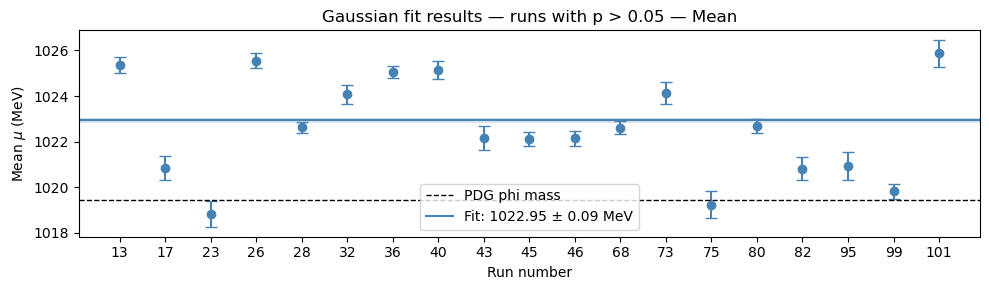

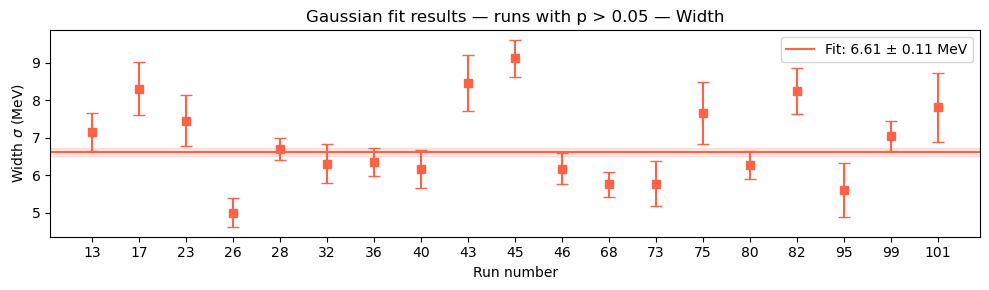

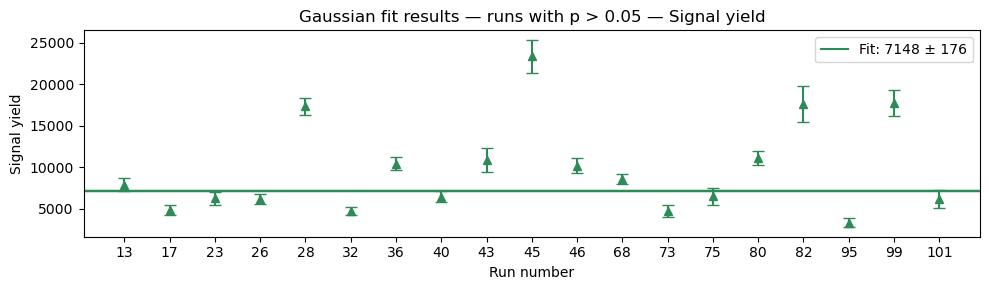

In [160]:
pval_cut = 0.05
good = results[results.pval > pval_cut].copy()
print(f'{len(good)} / {len(results)} runs pass p > {pval_cut}\n')
print(good[['n_sig','n_sig_err','mu','mu_err','sigma','sigma_err','chi2_ndf','pval']].to_string())

runs_good = good.index.to_numpy()
x = np.arange(len(runs_good))

w_mu = 1 / good.mu_err**2
mu_fit = (w_mu * good.mu).sum() / w_mu.sum()
mu_fit_err = 1 / np.sqrt(w_mu.sum())

w_sig = 1 / good.sigma_err**2
sigma_fit = (w_sig * good.sigma).sum() / w_sig.sum()
sigma_fit_err = 1 / np.sqrt(w_sig.sum())

w_nsig = 1 / good.n_sig_err**2
nsig_fit = (w_nsig * good.n_sig).sum() / w_nsig.sum()
nsig_fit_err = 1 / np.sqrt(w_nsig.sum())

# --- Plot 1: Mean mu ---
fig1, ax1 = plt.subplots(figsize=(10, 3))
ax1.errorbar(x, good.mu, yerr=good.mu_err, fmt='o', color='steelblue', capsize=4)
ax1.axhline(m_phi, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
ax1.axhline(mu_fit, color='steelblue', linestyle='-', linewidth=1.5, label=f'Fit: {mu_fit:.2f} ± {mu_fit_err:.2f} MeV')
ax1.axhspan(mu_fit - mu_fit_err, mu_fit + mu_fit_err, color='steelblue', alpha=0.15)
ax1.set_ylabel('Mean $\\mu$ (MeV)')
ax1.set_xticks(x); ax1.set_xticklabels(runs_good); ax1.set_xlabel('Run number')
ax1.set_title(f'Gaussian fit results — runs with p > {pval_cut} — Mean')
ax1.legend()
fig1.tight_layout()
fig1.savefig(plot_dir + 'summary_good_mu.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Width sigma ---
fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.errorbar(x, good.sigma, yerr=good.sigma_err, fmt='s', color='tomato', capsize=4)
ax2.axhline(sigma_fit, color='tomato', linestyle='-', linewidth=1.5, label=f'Fit: {sigma_fit:.2f} ± {sigma_fit_err:.2f} MeV')
ax2.axhspan(sigma_fit - sigma_fit_err, sigma_fit + sigma_fit_err, color='tomato', alpha=0.15)
ax2.set_ylabel('Width $\\sigma$ (MeV)')
ax2.set_xticks(x); ax2.set_xticklabels(runs_good); ax2.set_xlabel('Run number')
ax2.set_title(f'Gaussian fit results — runs with p > {pval_cut} — Width')
ax2.legend()
fig2.tight_layout()
fig2.savefig(plot_dir + 'summary_good_sigma.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Signal yield ---
fig3, ax3 = plt.subplots(figsize=(10, 3))
ax3.errorbar(x, good.n_sig, yerr=good.n_sig_err, fmt='^', color='seagreen', capsize=4)
ax3.axhline(nsig_fit, color='seagreen', linestyle='-', linewidth=1.5, label=f'Fit: {nsig_fit:.0f} ± {nsig_fit_err:.0f}')
ax3.axhspan(nsig_fit - nsig_fit_err, nsig_fit + nsig_fit_err, color='seagreen', alpha=0.15)
ax3.set_ylabel('Signal yield')
ax3.set_xticks(x); ax3.set_xticklabels(runs_good); ax3.set_xlabel('Run number')
ax3.set_title(f'Gaussian fit results — runs with p > {pval_cut} — Signal yield')
ax3.legend()
fig3.tight_layout()
fig3.savefig(plot_dir + 'summary_good_yield.png', dpi=150, bbox_inches='tight')
plt.show()
